In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

In [2]:
crop_df = pd.read_csv(r"C:\Users\Admin\Desktop\ML_Lab\crop_production.csv")
air_df = pd.read_csv(r"C:\Users\Admin\Desktop\ML_Lab\city_day.csv")

In [3]:
print("Crop Dataset Shape:", crop_df.shape)
print("Air Quality Dataset Shape:", air_df.shape)

Crop Dataset Shape: (246091, 7)
Air Quality Dataset Shape: (29531, 16)


In [4]:
air_df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
# Convert Date column to datetime format
air_df['Date'] = pd.to_datetime(air_df['Date'])

# Extract Year from Date
air_df['Year'] = air_df['Date'].dt.year

# Verify extraction
air_df[['Date', 'Year']].head()

,Date,Year
0,2015-01-01,2015
1,2015-01-02,2015
2,2015-01-03,2015
3,2015-01-04,2015
4,2015-01-05,2015


In [6]:
yearly_aqi = air_df.groupby('Year')['AQI'].mean().reset_index()

yearly_aqi

,Year,AQI
0,2015,212.463054
1,2016,197.150019
2,2017,181.472789
3,2018,182.684312
4,2019,156.518173
5,2020,113.520697


In [7]:
most_polluted = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
least_polluted = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]

print("Most Polluted Year:")
print(most_polluted)

print("\nLeast Polluted Year:")
print(least_polluted)

Most Polluted Year:
Year    2015.000000
AQI      212.463054
Name: 0, dtype: float64

Least Polluted Year:
Year    2020.000000
AQI      113.520697
Name: 5, dtype: float64


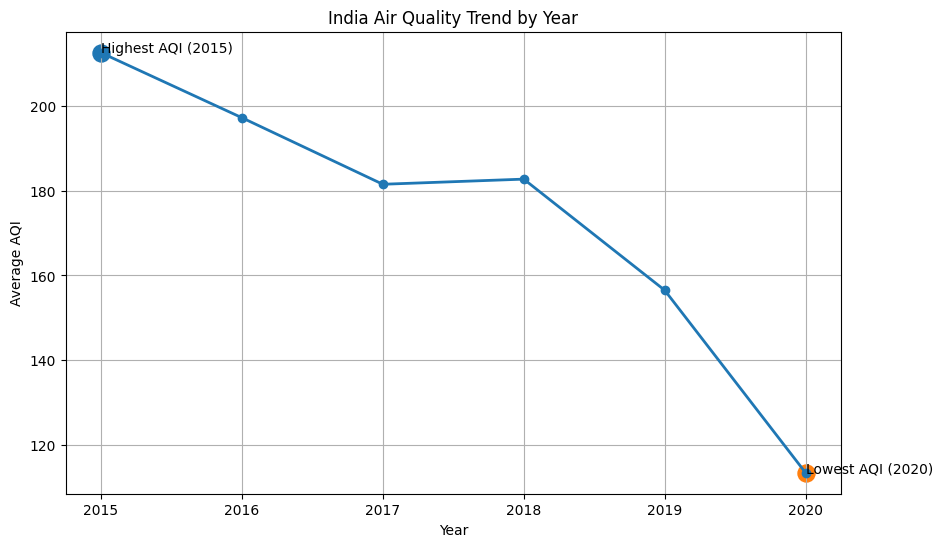

In [8]:
plt.figure(figsize=(10,6))

plt.plot(yearly_aqi['Year'],
         yearly_aqi['AQI'],
         marker='o',
         linewidth=2)

plt.scatter(most_polluted['Year'],
            most_polluted['AQI'],
            s=150)

plt.scatter(least_polluted['Year'],
            least_polluted['AQI'],
            s=150)

plt.annotate(f"Highest AQI ({int(most_polluted['Year'])})",
             (most_polluted['Year'], most_polluted['AQI']))

plt.annotate(f"Lowest AQI ({int(least_polluted['Year'])})",
             (least_polluted['Year'], least_polluted['AQI']))

plt.title("India Air Quality Trend by Year")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)

plt.show()

### Journalist Response

Based on the yearly average AQI values from 2015 to 2020, India's air quality has generally improved over time. The average AQI decreased from 212.46 in 2015 to 113.52 in 2020, indicating a significant reduction in pollution levels. Although there was a slight increase in AQI during 2018 compared to 2017, the overall trend is downward. The most polluted year in the dataset was 2015 with an average AQI of 212.46, while 2020 recorded the lowest average AQI of 113.52. These findings suggest that air quality has improved during the period covered by the dataset, and pollution control measures introduced after 2018 may have contributed to this improvement.

In [9]:
#Task 7

In [10]:
air_df['Month'] = air_df['Date'].dt.month

air_df[['Date', 'Month']].head()

,Date,Month
0,2015-01-01,1
1,2015-01-02,1
2,2015-01-03,1
3,2015-01-04,1
4,2015-01-05,1


In [11]:
monthly_aqi = air_df.groupby('Month')['AQI'].mean().reset_index()

monthly_aqi

,Month,AQI
0,1,231.674918
1,2,202.905197
2,3,164.735281
3,4,143.355120
4,5,135.489579
5,6,120.198379
6,7,111.854575
7,8,113.613176
8,9,115.191804
9,10,188.613552


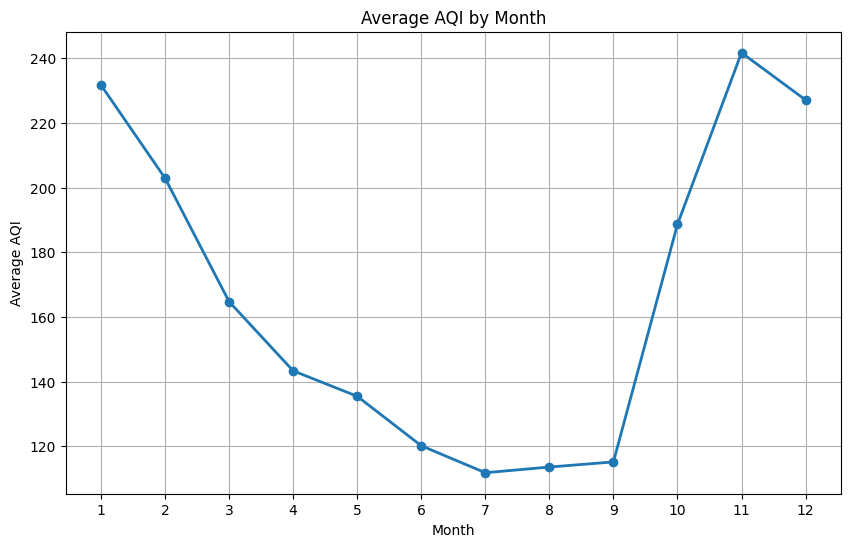

In [12]:
plt.figure(figsize=(10,6))

plt.plot(monthly_aqi['Month'],
         monthly_aqi['AQI'],
         marker='o',
         linewidth=2)

plt.title('Average AQI by Month')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(range(1,13))
plt.grid(True)

plt.show()

### Response to NGO Claim

Based on the monthly average AQI values, the NGO's claim is supported by the data. Air quality follows a clear seasonal pattern throughout the year. AQI levels gradually decrease from January to September, reaching their lowest levels during the monsoon period. However, pollution levels increase sharply during October and remain very high through November and December. November records the highest average AQI (241.68), while October (188.61) and December (227.08) also show significantly elevated pollution levels. These findings indicate that air quality is generally worst during the October–December harvest season, supporting the NGO's concern that seasonal activities such as crop residue burning may contribute to increased air pollution.

In [ ]:
#Task 8

In [13]:
crop_df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


In [14]:
crop_df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production'],
      dtype='object')

In [15]:
air_df['City'].unique()[:20]

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow'],
      dtype=object)

In [16]:
air_df['City'].nunique()

26

In [17]:
air_df.columns

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Year',
       'Month'],
      dtype='object')

In [18]:
air_df['City'].nunique()

26

In [19]:
sorted(air_df['City'].unique())

['Ahmedabad',
 'Aizawl',
 'Amaravati',
 'Amritsar',
 'Bengaluru',
 'Bhopal',
 'Brajrajnagar',
 'Chandigarh',
 'Chennai',
 'Coimbatore',
 'Delhi',
 'Ernakulam',
 'Gurugram',
 'Guwahati',
 'Hyderabad',
 'Jaipur',
 'Jorapokhar',
 'Kochi',
 'Kolkata',
 'Lucknow',
 'Mumbai',
 'Patna',
 'Shillong',
 'Talcher',
 'Thiruvananthapuram',
 'Visakhapatnam']

In [ ]:
#Aggregate Air Data to Year Level
air_yearly = air_df.groupby('Year').mean(numeric_only=True).reset_index()

air_yearly.head()

,Year,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Month
0,2015,83.323750,186.018164,16.588714,23.729427,35.541396,37.713707,4.205297,13.513310,32.919829,4.290253,7.150069,1.679289,212.463054,6.788290
1,2016,92.223729,145.500156,19.408612,31.362462,30.861736,39.499053,1.807855,10.063124,38.121916,2.330611,5.605426,1.538078,197.150019,6.671363
2,2017,86.034757,129.082620,17.666010,31.963634,24.023689,30.365794,1.256459,12.225970,34.409825,1.600159,4.477028,2.495127,181.472789,7.000213
3,2018,69.230657,133.263001,18.813078,33.353737,37.169719,21.890958,3.004921,18.171016,35.221742,2.692337,11.085401,4.818564,182.684312,6.592490
4,2019,58.958241,112.964335,16.443662,28.497536,33.337306,18.965398,2.298988,16.353351,33.051420,3.298604,10.916312,4.009622,156.518173,6.821246


In [ ]:
#Aggregate Crop Data to Year Level
crop_yearly = crop_df.groupby('Crop_Year')[['Production', 'Area']].sum().reset_index()

crop_yearly.head()

,Crop_Year,Production,Area
0,1997,8.512329e+08,2.317150e+08
1,1998,5.825321e+09,1.669881e+08
2,1999,6.434666e+09,1.586661e+08
3,2000,7.449709e+09,1.652975e+08
4,2001,7.465541e+09,1.652956e+08


In [22]:
#Keep Only Common Years and Merge
#Your air data is available for 2015–2020, so we need to merge on year.
merged_df = pd.merge(
    air_yearly,
    crop_yearly,
    left_on='Year',
    right_on='Crop_Year',
    how='inner'
)

merged_df.head()

,Year,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Month,Crop_Year,Production,Area
0,2015,83.32375,186.018164,16.588714,23.729427,35.541396,37.713707,4.205297,13.51331,32.919829,4.290253,7.150069,1.679289,212.463054,6.78829,2015,6935064.7,4601298.0


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


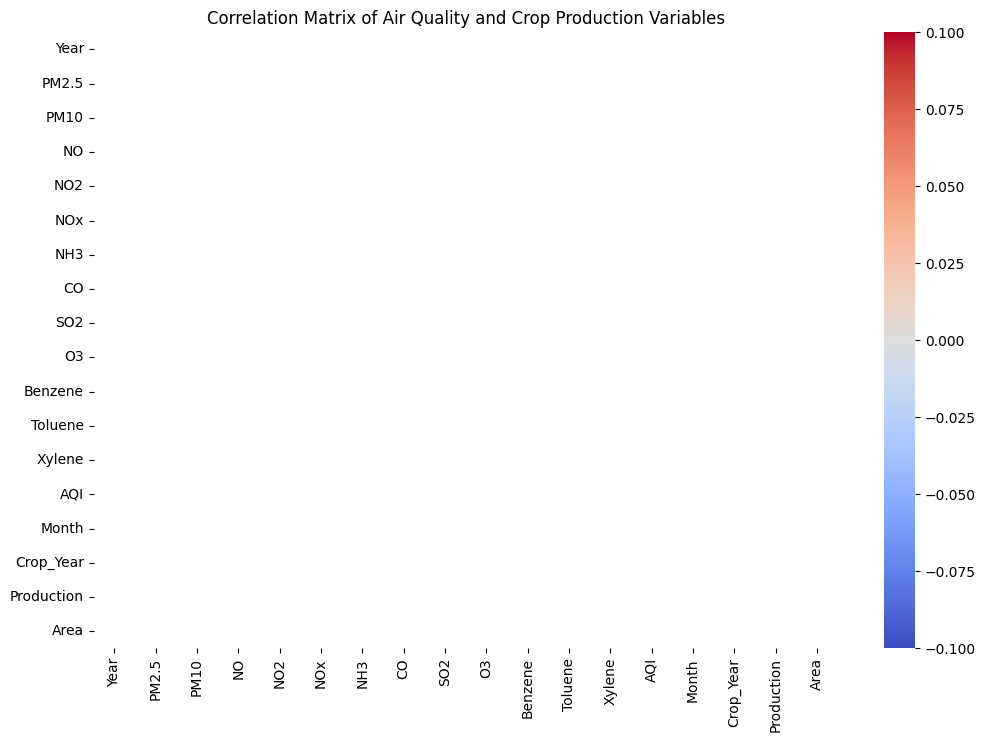

In [23]:
corr_matrix = merged_df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix of Air Quality and Crop Production Variables')
plt.show()

In [24]:
merged_df.shape

(1, 18)

In [25]:
merged_df[['Year','Crop_Year']]

,Year,Crop_Year
0,2015,2015


In [26]:
print("Air Years:")
print(sorted(air_yearly['Year'].unique()))

print("\nCrop Years:")
print(sorted(crop_yearly['Crop_Year'].unique())[-10:])

Air Years:
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]

Crop Years:
[np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]


In [27]:
crop_yearly[crop_yearly['Crop_Year'] >= 2015]

,Crop_Year,Production,Area
18,2015,6935064.7,4601298.0


In [28]:
print("Air dataset year range:", air_df['Year'].min(), "-", air_df['Year'].max())
print("Crop dataset year range:", crop_df['Crop_Year'].min(), "-", crop_df['Crop_Year'].max())

Air dataset year range: 2015 - 2020
Crop dataset year range: 1997 - 2015


The air quality dataset was collected at the city-day level, while the crop production dataset was collected at the state-year level.
To make the datasets compatible, the air quality data was aggregated from daily observations to yearly average values. Similarly,
the crop production data was aggregated to yearly totals for production and cultivated area. After transforming both datasets 
to a common yearly level, they were merged using the year field. However, the air quality dataset covers the period 2015–2020, 
whereas the crop production dataset covers 1997–2015. Therefore, only the year 2015 was common between the two datasets, 
resulting in a merged dataset containing a single record.


The objective was to investigate whether states with poorer air quality tend to produce less crop output. 
However, after transforming and merging the datasets, only one common year (2015) was available.
Correlation analysis requires multiple observations to identify meaningful relationships between variables.
Since the merged dataset contains only a single record, no statistically valid correlations can be calculated. 
Therefore, it is not possible to identify reliable relationships between air quality indicators and 
crop production using the available data. To perform this analysis properly, additional crop production data beyond 2015 or air quality data before 2015 would be required.


**Briefing for the State Environment Minister**

Minister,

Our analysis of the air quality data shows three important findings. First, air quality generally improved between 2015 and 2020. Average pollution levels decreased steadily over the period, suggesting that conditions have become better compared to earlier years. Second, pollution follows a strong seasonal pattern. The highest pollution levels occur during October, November, and December, with November showing the worst air quality. This supports concerns that activities during the harvest season contribute to increased pollution. Third, pollution levels are lowest during the monsoon months, indicating that weather and seasonal factors have a major influence on air quality.

For farmers, this means that poor air quality is not evenly distributed throughout the year. Pollution is concentrated during specific months, which may affect health, visibility, and overall living conditions in farming communities.

Based on these findings, I recommend strengthening pollution-control measures during the October–December period, including monitoring and reducing practices that contribute to seasonal pollution.

One important limitation is that we could not reliably determine whether poor air quality reduces crop production. The available air quality and crop datasets overlap for only one year, so the current data cannot prove a direct connection between pollution and agricultural output.
